In [2]:
%cd /home/govind/gov_semproject/GridCellsCopy

/home/govind/gov_semproject/GridCellsCopy


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import g_utils
import analysis_utils as a_utils
from interneuron import Interneuron
import sim_utils as s_utils
from neuron import h
import importlib
importlib.reload(g_utils)
h.load_file("stdrun.hoc")
h.celsius=37
#h.cvode_active(1)

Current : 0.0nA
[]
Current : 0.001nA
[  17.225        35.625        53.025        69.1          84.8
  101.2         119.          137.4         154.625       170.625
  186.35        202.85        220.775       239.125       256.25
  272.15        287.9         304.525       322.575       340.875
  357.8         373.675       389.45        406.225       424.375
  442.575       459.4         475.2         491.05        507.95
  526.2         544.275       560.975       576.725       592.625
  609.675       628.          645.975       662.55        678.275
  694.225       711.425       729.775       747.625       764.05
  779.75        795.8         813.125       831.525       849.25
  865.6         881.275       897.4         914.85        933.3
  950.9         967.125       982.825       999.025      1016.625
 1035.05       1052.5        1068.625      1084.325      1100.65
 1118.35       1136.775      1154.075      1170.125      1185.825
 1202.275      1220.1        1238.475      1255.

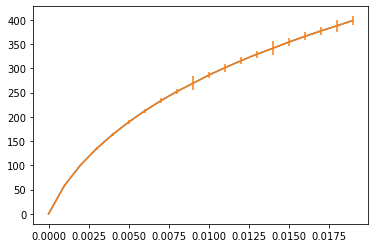

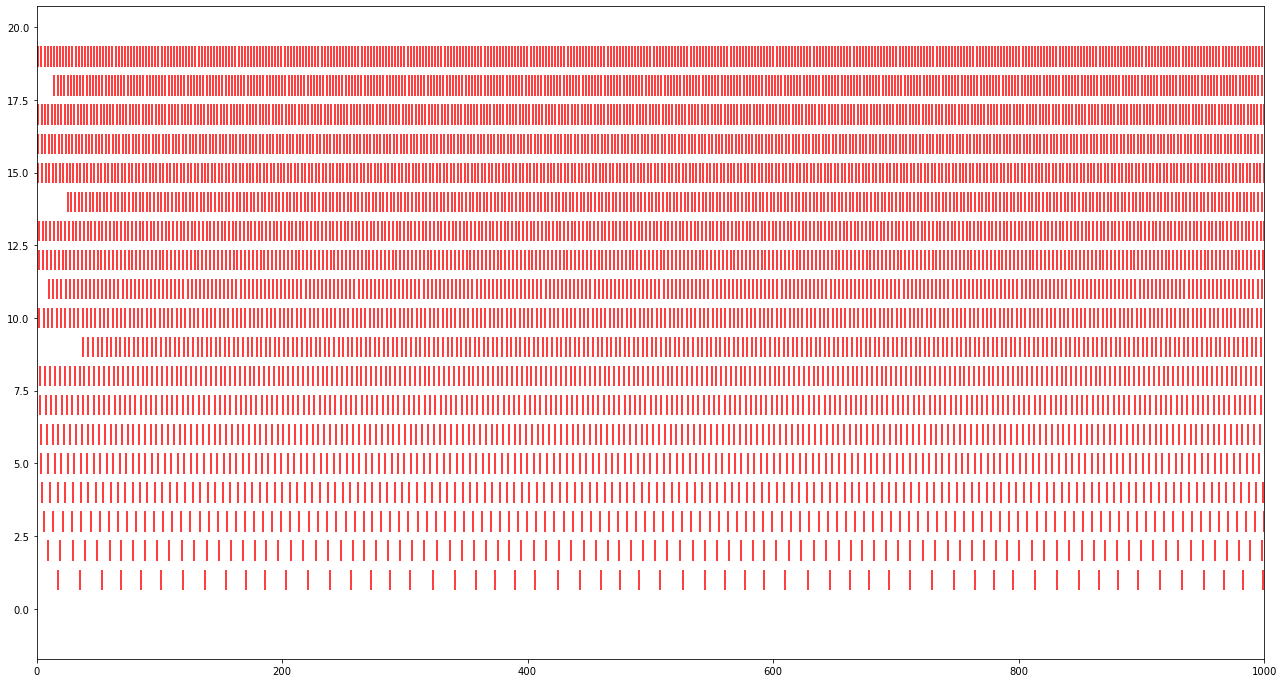

In [18]:
test_interneuron = Interneuron(0)

def f_i_const_curr(curr_amp,time_ms,sigma=50,osc_amp=0):
    
    ic = h.IClamp(test_interneuron.soma(0.5))
    #ic.delay=0
    ic.dur = 1e9
    freq=40
    
    #ic_amp = curr_amp
    T,num_steps = time_ms/1000, time_ms
    time_arr = np.linspace(0,T,num_steps)
    curr_arr = np.full(time_arr.shape,curr_amp)
    theta_arr = osc_amp*np.sin(2*np.pi*freq*time_arr)
    curr_vec = h.Vector(curr_arr+theta_arr)
    
    curr_vec.play(ic, ic._ref_amp, True)
    rec_i = h.Vector().record(ic._ref_amp)
    rec_v = h.Vector().record(test_interneuron.soma(0.5)._ref_v)
    rec_t = h.Vector().record(h._ref_t)
    spike_times = h.Vector()

    nc = h.NetCon(test_interneuron.soma(0.5)._ref_v, None, sec=test_interneuron.soma)
    nc.threshold=0
    nc.record(spike_times)

    h.finitialize(-70)
    h.continuerun(time_ms)

    np_spike_array = np.array(spike_times.to_python())
    print(np_spike_array)
    firing_rate = a_utils.instant_rate(spike_train=spike_times,sim_dur=time_ms,stdev=sigma)*1000 #converting to Hz
    
    del nc,ic,spike_times
    #g_utils.plot_power_spectrum(firing_rate,xmax=500)
    return np.mean(firing_rate), np.std(firing_rate),np_spike_array

    

curr_amp_list = [i*1e-3 for i in range(0,20,1)]
freq_mean_list=[]
freq_std_list =[]
spikes_list=[]
for amp in curr_amp_list:
    print(f"Current : {amp}nA")
    mean,std,spikes = f_i_const_curr(curr_amp=amp,time_ms=10000,sigma=20,osc_amp=0)
    freq_mean_list.append(mean)
    freq_std_list.append(std)
    spikes_list.append(spikes)

plt.plot(curr_amp_list,freq_mean_list)
plt.errorbar(curr_amp_list,freq_mean_list,yerr=freq_std_list)
plt.show()
plt.figure(figsize=(22,12))
plt.eventplot(spikes_list,colors='red',linelengths=0.7)
plt.xlim(0,1000)
plt.show()


